# Sistem Hibrida Deteksi Cyberbullying Bahasa Indonesia

Notebook ini mengimplementasikan sistem deteksi kata/frasa cyberbullying dan hate speech bahasa Indonesia menggunakan pendekatan hibrida:

1. **Metode Berbasis Aturan (Leksikon & Normalisasi Teks)**:
   - Mendeteksi variasi kata samaran (*obfuscation*) menggunakan angka/simbol (*leetspeak*), underscore, spasi berlebih, atau huruf berulang (contoh: `M4ti lu`, `d4s4r g0bl0k`, `b@@@nngs444t`).
   - Menormalisasi kata singkatan/slang gaul menjadi kata formal menggunakan kamus pemetaan (contoh: `gblk` -> `goblok`, `lu` -> `kamu`, `yg` -> `yang`).
   - Mencocokkan teks dengan leksikon cyberbullying yang terdiri atas **139 kata kasar**.

2. **Metode Klasifikasi Machine Learning (Supervised Learning)**:
   - Melatih model klasifikasi **Multinomial Naive Bayes** dan **Logistic Regression** menggunakan representasi fitur **TF-IDF Vectorizer** (unigram & bigram).
   - Model dilatih menggunakan dataset media sosial bahasa Indonesia berlabel.

3. **Metode Deep Learning (Transformers)**:
   - Menggunakan model Transformer tingkat lanjut **XLM-RoBERTa** yang telah dilatih khusus untuk mendeteksi hate speech & abusive text bahasa Indonesia untuk pemahaman konteks mendalam (sarkasme/sentimen).

---

### Dataset yang Digunakan dalam Proyek Ini:
- **Dataset Instagram (kairaamilanii)**: Berisi 650 komentar Instagram berlabel biner (`Bullying` vs `Non-bullying`).
- **Dataset Twitter (ilhamfp31)**: Berisi 13.169 tweet dengan pelabelan multi-label (`Abusive`, `Hate Speech`, `SARA`, dll.).
- **Dataset Kompilasi (leonss0711)**: Penggabungan data berlabel dari berbagai sumber (total 2.153 baris) untuk analisis benchmark yang adil.

In [1]:
# Library standar Python + pandas untuk tabel
import re
import html
import unicodedata
from difflib import SequenceMatcher
from typing import List, Dict, Any

import pandas as pd

## 1. Kamus Leetspeak, Kamus Slang, dan Fungsi Normalisasi

Fungsi normalisasi di bawah ini akan:

1. Mengubah teks menjadi huruf kecil.
2. Mengubah angka/simbol tertentu menjadi huruf yang umum dipakai untuk menyamarkan kata (*leetspeak*), misalnya `4 → a`, `1 → i`, `0 → o`.
3. Menghapus atau menetralkan simbol, underscore, tanda baca, dan spasi berlebihan.
4. Menerjemahkan kata slang/singkatan tidak baku (seperti `gblk`, `anjg`, `lu`, `yg`) menjadi kata baku/formal bahasa Indonesia menggunakan kamus pemetaan slang (`new_kamusalay.csv` & `kamus_singkatan.csv`).
5. Membuat dua versi teks hasil normalisasi:
   - `spaced`: hasil normalisasi yang diselaraskan dengan kata baku, cocok untuk pencocokan berbasis kata (word match).
   - `compact`: seluruh simbol dan spasi dihapus untuk menangkap bentuk tersamar ekstrim, misalnya `M_4t1     l___U` -> `matilu`.

In [2]:
# Peta pengganti karakter yang umum dipakai untuk menyamarkan kata.
# Silakan tambah sesuai pola bahasa pengguna di dataset Anda.
LEET_MAP = {
    "0": "o",
    "1": "i",
    "!": "i",
    "|": "i",
    "¡": "i",
    "3": "e",
    "4": "a",
    "@": "a",
    "5": "s",
    "$": "s",
    "7": "t",
    "+": "t",
    "8": "b",
    "9": "g",
    "6": "g",
}

ZERO_WIDTH_RE = re.compile(r"[\u200B-\u200D\uFEFF]")
NON_ALNUM_RE = re.compile(r"[^a-z0-9]+")
MULTISPACE_RE = re.compile(r"\s+")
REPEATED_CHAR_RE = re.compile(r"(.)\1{2,}")
REPEATED_CHAR_ANY_RE = re.compile(r"(.)\1+")


def replace_leet(text: str) -> str:
    """Mengganti karakter leetspeak menjadi huruf latin yang paling mendekati."""
    return "".join(LEET_MAP.get(ch, ch) for ch in text)


def reduce_repeated_chars(text: str, max_repeat: int = 2) -> str:
    """Mengurangi huruf yang diulang berlebihan, misalnya 'maaatii' -> 'maatii'."""
    if max_repeat < 1:
        return text
    if max_repeat == 1:
        return REPEATED_CHAR_ANY_RE.sub(lambda m: m.group(1), text)
    return REPEATED_CHAR_RE.sub(lambda m: m.group(1) * max_repeat, text)


# Memuat kamus slang alay & singkatan bahasa Indonesia
# Kamus ini akan menormalisasi kata gaul/singkat menjadi bahasa formal sebelum pencocokan leksikon
print("Memuat kamus slang alay & singkatan...")
try:
    alay_df = pd.read_csv('dataset 1/new_kamusalay.csv', encoding='latin-1', header=None, names=['slang', 'formal'])
    alay_map = dict(zip(alay_df['slang'], alay_df['formal']))
except Exception as e:
    print("Warning: Gagal memuat new_kamusalay.csv:", e)
    alay_map = {}

try:
    singkatan_df = pd.read_csv('dataset 2/kamus_singkatan.csv', encoding='latin-1')
    singkatan_df = singkatan_df.dropna(subset=['singkatan', 'asli'])
    singkatan_map = dict(zip(singkatan_df['singkatan'], singkatan_df['asli']))
except Exception as e:
    print("Warning: Gagal memuat kamus_singkatan.csv:", e)
    singkatan_map = {}

# Gabungkan pemetaan slang & singkatan
SLANG_MAP = {**singkatan_map, **alay_map}
print(f"Berhasil memuat {len(SLANG_MAP)} aturan pemetaan slang/singkatan.")


def normalize_text(text: Any, reduce_repeats: bool = True) -> Dict[str, str]:
    """
    Menghasilkan tiga bentuk normalisasi:
    - spaced: simbol menjadi spasi, cocok untuk deteksi kata/frasa normal.
    - compact: seluruh simbol dan spasi dihapus, cocok untuk deteksi obfuscation.
    - compact_strict: compact dengan huruf berulang dijadikan satu, misalnya 'g0bllloook' -> 'goblok'.
    """
    if pd.isna(text):
        text = ""
    text = str(text)

    # Decode entity HTML, normalisasi unicode, lowercase, hapus zero-width char
    raw = html.unescape(text)
    raw = unicodedata.normalize("NFKC", raw)
    raw = ZERO_WIDTH_RE.sub("", raw)
    raw = raw.lower()

    # Ganti variasi leetspeak
    leet_replaced = replace_leet(raw)

    # Ubah non-alfanumerik menjadi spasi
    spaced = NON_ALNUM_RE.sub(" ", leet_replaced)
    spaced = MULTISPACE_RE.sub(" ", spaced).strip()

    # Terapkan normalisasi kata slang/gaul & singkatan jika tersedia
    if SLANG_MAP:
        words = spaced.split()
        spaced = " ".join(SLANG_MAP.get(w, w) for w in words)

    # Compact: buang semua non-alfanumerik
    compact_raw = NON_ALNUM_RE.sub("", leet_replaced)

    if reduce_repeats:
        spaced = reduce_repeated_chars(spaced, max_repeat=2)
        compact = reduce_repeated_chars(compact_raw, max_repeat=2)
        compact_strict = reduce_repeated_chars(compact_raw, max_repeat=1)
    else:
        compact = compact_raw
        compact_strict = compact_raw

    return {
        "raw": text,
        "spaced": spaced,
        "compact": compact,
        "compact_strict": compact_strict,
    }


# Tes cepat normalisasi
for sample in ["Mati lu", "M4ti lu", "M_4t1     l___U", "m a t i  l u", "d4s4r g0bl0k!!!", "b@@@nngs444t"]:
    print(sample, "=>", normalize_text(sample))


Memuat kamus slang alay & singkatan...
Berhasil memuat 15578 aturan pemetaan slang/singkatan.
Mati lu => {'raw': 'Mati lu', 'spaced': 'mati kamu', 'compact': 'matilu', 'compact_strict': 'matilu'}
M4ti lu => {'raw': 'M4ti lu', 'spaced': 'mati kamu', 'compact': 'matilu', 'compact_strict': 'matilu'}
M_4t1     l___U => {'raw': 'M_4t1     l___U', 'spaced': 'sama hati l kamu', 'compact': 'matilu', 'compact_strict': 'matilu'}
m a t i  l u => {'raw': 'm a t i  l u', 'spaced': 'sama a t i l kamu', 'compact': 'matilu', 'compact_strict': 'matilu'}
d4s4r g0bl0k!!! => {'raw': 'd4s4r g0bl0k!!!', 'spaced': 'dasar goblokii', 'compact': 'dasargoblokii', 'compact_strict': 'dasargobloki'}
b@@@nngs444t => {'raw': 'b@@@nngs444t', 'spaced': 'baanngsaat', 'compact': 'baanngsaat', 'compact_strict': 'bangsat'}


## 2. Kamus Kata/Frasa Cyberbullying

Kamus ini sengaja dibuat mudah diedit. Tambahkan kata/frasa sesuai kebutuhan dataset Anda.

Kolom penting:

- `phrase`: kata/frasa target.
- `category`: kategori pelanggaran.
- `severity`: tingkat risiko awal, yaitu `rendah`, `sedang`, atau `tinggi`.

In [3]:
CYBERBULLYING_LEXICON = [
    # Ancaman, dorongan kekerasan, atau serangan personal berat
    {"phrase": "mati lu", "category": "ancaman/serangan personal", "severity": "tinggi"},
    {"phrase": "mati lo", "category": "ancaman/serangan personal", "severity": "tinggi"},
    {"phrase": "mati loe", "category": "ancaman/serangan personal", "severity": "tinggi"},
    {"phrase": "mati kamu", "category": "ancaman/serangan personal", "severity": "tinggi"},
    {"phrase": "mending mati", "category": "dorongan menyakiti diri", "severity": "tinggi"},
    {"phrase": "bunuh diri", "category": "dorongan menyakiti diri", "severity": "tinggi"},
    {"phrase": "ga usah hidup", "category": "dorongan menyakiti diri", "severity": "tinggi"},
    {"phrase": "nggak usah hidup", "category": "dorongan menyakiti diri", "severity": "tinggi"},

    # Hinaan langsung
    {"phrase": "dasar bodoh", "category": "hinaan", "severity": "sedang"},
    {"phrase": "dasar goblok", "category": "hinaan", "severity": "sedang"},
    {"phrase": "dasar tolol", "category": "hinaan", "severity": "sedang"},
    {"phrase": "dasar bego", "category": "hinaan", "severity": "sedang"},
    {"phrase": "dasar sampah", "category": "hinaan", "severity": "sedang"},
    {"phrase": "otak kosong", "category": "hinaan", "severity": "sedang"},

    # Kata kasar umum. Deteksi kata tunggal lebih rawan false positive, jadi tetap perlu validasi konteks.
    {"phrase": "goblok", "category": "kata kasar", "severity": "sedang"},
    {"phrase": "tolol", "category": "kata kasar", "severity": "sedang"},
    {"phrase": "bodoh", "category": "kata kasar", "severity": "rendah"},
    {"phrase": "bego", "category": "kata kasar", "severity": "rendah"},
    {"phrase": "idiot", "category": "kata kasar", "severity": "sedang"},
    {"phrase": "sampah", "category": "kata kasar", "severity": "sedang"},
    {"phrase": "anjing", "category": "kata kasar", "severity": "sedang"},
    {"phrase": "bangsat", "category": "kata kasar", "severity": "sedang"},
    {"phrase": "babi", "category": "kata kasar", "severity": "sedang"},
    {"phrase": "kampret", "category": "kata kasar", "severity": "rendah"},
]


def prepare_lexicon(lexicon: List[Dict[str, str]]) -> List[Dict[str, str]]:
    prepared = []
    for item in lexicon:
        norm = normalize_text(item["phrase"], reduce_repeats=False)
        prepared.append({
            **item,
            "norm_spaced": norm["spaced"],
            "norm_compact": norm["compact"],
            "word_count": len(norm["spaced"].split()),
        })
    return prepared


PREPARED_LEXICON = prepare_lexicon(CYBERBULLYING_LEXICON)
pd.DataFrame(PREPARED_LEXICON).head(10)

,phrase,category,severity,norm_spaced,norm_compact,word_count
0,mati lu,ancaman/serangan personal,tinggi,mati kamu,matilu,2
1,mati lo,ancaman/serangan personal,tinggi,mati kamu,matilo,2
2,mati loe,ancaman/serangan personal,tinggi,mati kamu,matiloe,2
3,mati kamu,ancaman/serangan personal,tinggi,mati kamu,matikamu,2
4,mending mati,dorongan menyakiti diri,tinggi,mending mati,mendingmati,2
5,bunuh diri,dorongan menyakiti diri,tinggi,bunuh diri,bunuhdiri,2
6,ga usah hidup,dorongan menyakiti diri,tinggi,tidak usah hidup,gausahhidup,3
7,nggak usah hidup,dorongan menyakiti diri,tinggi,enggak usah hidup,nggakusahhidup,3
8,dasar bodoh,hinaan,sedang,dasar bodoh,dasarbodoh,2
9,dasar goblok,hinaan,sedang,dasar goblok,dasargoblok,2


## 3. Mesin Deteksi

Metode deteksi menggunakan tiga lapis:

1. `word_or_phrase_match`: pencocokan kata/frasa pada teks yang sudah dinormalisasi dengan spasi.
2. `compact_match`: pencocokan pada teks tanpa spasi/simbol untuk menangkap bentuk seperti `M_4t1     l___U`.
3. `fuzzy_compact_match`: pencocokan mirip, opsional, untuk variasi yang tidak sepenuhnya tertangkap oleh peta leetspeak. Metode fuzzy lebih rawan false positive, sehingga threshold dibuat cukup tinggi.

In [4]:
SEVERITY_SCORE = {
    "rendah": 1,
    "sedang": 2,
    "tinggi": 3,
}


def contains_word_or_phrase(spaced_text: str, spaced_pattern: str) -> bool:
    """Mencocokkan kata/frasa dengan batas kata agar lebih aman dari false positive."""
    if not spaced_pattern:
        return False
    pattern = r"(?<![a-z0-9])" + re.escape(spaced_pattern) + r"(?![a-z0-9])"
    return re.search(pattern, spaced_text) is not None


def fuzzy_contains(compact_text: str, compact_pattern: str, threshold: float = 0.92, max_delta: int = 2) -> bool:
    """
    Mengecek apakah pattern kira-kira ada di compact_text.
    Dipakai sebagai fallback. Gunakan threshold tinggi untuk mengurangi false positive.
    """
    if not compact_text or not compact_pattern:
        return False

    n = len(compact_pattern)
    if n < 5 or len(compact_text) < max(3, n - max_delta):
        return False

    min_len = max(3, n - max_delta)
    max_len = n + max_delta

    for size in range(min_len, max_len + 1):
        if size > len(compact_text):
            continue
        for i in range(0, len(compact_text) - size + 1):
            segment = compact_text[i:i + size]
            ratio = SequenceMatcher(None, segment, compact_pattern).ratio()
            if ratio >= threshold:
                return True
    return False


def detect_cyberbullying_text(
    text: Any,
    lexicon: List[Dict[str, str]] = PREPARED_LEXICON,
    use_fuzzy: bool = True,
    fuzzy_threshold: float = 0.92,
) -> Dict[str, Any]:
    """
    Mengembalikan hasil deteksi untuk satu teks.
    """
    norm = normalize_text(text)
    spaced_text = norm["spaced"]
    compact_text = norm["compact"]
    compact_strict_text = norm["compact_strict"]

    matches = []
    seen_phrases = set()

    for item in lexicon:
        phrase = item["phrase"]
        norm_spaced = item["norm_spaced"]
        norm_compact = item["norm_compact"]

        method = None

        # 1) Deteksi frasa/kata normal setelah normalisasi spasi
        if contains_word_or_phrase(spaced_text, norm_spaced):
            method = "word_or_phrase_match"

        # 2) Deteksi bentuk compact untuk simbol/spasi/underscore berlebihan
        elif norm_compact and norm_compact in compact_text:
            method = "compact_match"

        # 3) Deteksi huruf yang diulang berlebihan: g0bllloook -> goblok
        elif norm_compact and norm_compact in compact_strict_text:
            method = "compact_repeated_char_match"

        # 4) Fuzzy fallback, terutama untuk frasa panjang/risiko tinggi
        elif use_fuzzy and len(norm_compact) >= 6:
            if fuzzy_contains(compact_text, norm_compact, threshold=fuzzy_threshold) or fuzzy_contains(compact_strict_text, norm_compact, threshold=fuzzy_threshold):
                method = "fuzzy_compact_match"

        if method and phrase not in seen_phrases:
            matches.append({
                "matched_phrase": phrase,
                "category": item["category"],
                "severity": item["severity"],
                "method": method,
                "normalized_key": norm_compact,
            })
            seen_phrases.add(phrase)

    # Skor dan label risiko
    score = sum(SEVERITY_SCORE.get(m["severity"], 1) for m in matches)
    has_high = any(m["severity"] == "tinggi" for m in matches)

    if not matches:
        risk_label = "aman/tidak terdeteksi"
    elif has_high or score >= 4:
        risk_label = "tinggi"
    elif score >= 2:
        risk_label = "sedang"
    else:
        risk_label = "rendah"

    return {
        "text": str(text),
        "normalized_spaced": spaced_text,
        "normalized_compact": compact_text,
        "normalized_compact_strict": compact_strict_text,
        "is_cyberbullying": bool(matches),
        "risk_label": risk_label,
        "score": score,
        "matches": matches,
        "matched_phrases": ", ".join(sorted({m["matched_phrase"] for m in matches})),
        "matched_categories": ", ".join(sorted({m["category"] for m in matches})),
        "detection_methods": ", ".join(sorted({m["method"] for m in matches})),
    }

## 4. Uji Coba Deteksi

Sel berikut menguji teks normal dan teks yang sudah disamarkan.

In [5]:
test_texts = [
    "Semangat ya, jangan menyerah.",
    "Mati lu",
    "M4ti lu",
    "M_4t1     l___U",
    "m a t i  l u",
    "d4s4r g0bl0k kamu",
    "D_a_s_a_r    t0l0l!!!",
    "Kamu orangnya baik, tapi idemu kurang tepat.",
    "b@@@nngs444t banget sih",
    "g___o___b___l___o___k",
]

results = [detect_cyberbullying_text(t) for t in test_texts]
df_results = pd.DataFrame(results)

# Tampilkan kolom penting
pd.set_option("display.max_colwidth", 120)
df_results[[
    "text",
    "normalized_spaced",
    "normalized_compact",
    "normalized_compact_strict",
    "is_cyberbullying",
    "risk_label",
    "score",
    "matched_phrases",
    "matched_categories",
    "detection_methods",
]]

,text,normalized_spaced,normalized_compact,normalized_compact_strict,is_cyberbullying,risk_label,score,matched_phrases,matched_categories,detection_methods
0,"Semangat ya, jangan menyerah.",semangat ya jangan menyerah,semangatyajanganmenyerah,semangatyajanganmenyerah,False,aman/tidak terdeteksi,0,,,
1,Mati lu,mati kamu,matilu,matilu,True,tinggi,12,"mati kamu, mati lo, mati loe, mati lu",ancaman/serangan personal,word_or_phrase_match
2,M4ti lu,mati kamu,matilu,matilu,True,tinggi,12,"mati kamu, mati lo, mati loe, mati lu",ancaman/serangan personal,word_or_phrase_match
3,M_4t1 l___U,sama hati l kamu,matilu,matilu,True,tinggi,3,mati lu,ancaman/serangan personal,compact_match
4,m a t i l u,sama a t i l kamu,matilu,matilu,True,tinggi,3,mati lu,ancaman/serangan personal,compact_match
5,d4s4r g0bl0k kamu,dasar goblok kamu,dasargoblokkamu,dasargoblokamu,True,tinggi,4,"dasar goblok, goblok","hinaan, kata kasar",word_or_phrase_match
6,D_a_s_a_r t0l0l!!!,di a si a r tololii,dasartololii,dasartololi,True,tinggi,4,"dasar tolol, tolol","hinaan, kata kasar",compact_match
7,"Kamu orangnya baik, tapi idemu kurang tepat.",kamu orangnya baik tetapi idemu kurang tepat,kamuorangnyabaiktapiidemukurangtepat,kamuorangnyabaiktapidemukurangtepat,False,aman/tidak terdeteksi,0,,,
8,b@@@nngs444t banget sih,baanngsaat sekali sih,baanngsaatbangetsih,bangsatbangetsih,True,sedang,2,bangsat,kata kasar,compact_repeated_char_match
9,g___o___b___l___o___k,tidak o b l o ke,goblok,goblok,True,sedang,2,goblok,kata kasar,compact_match


## 5. Melihat Detail Match per Kalimat

Gunakan fungsi ini untuk melihat alasan sebuah teks ditandai sebagai cyberbullying.

In [6]:
def explain_detection(text: str) -> None:
    result = detect_cyberbullying_text(text)
    print("TEKS ASLI        :", result["text"])
    print("NORMALIZED      :", result["normalized_spaced"])
    print("COMPACT         :", result["normalized_compact"])
    print("TERDETEKSI      :", result["is_cyberbullying"])
    print("RISIKO          :", result["risk_label"])
    print("SKOR            :", result["score"])
    print("MATCHES:")
    if not result["matches"]:
        print("- Tidak ada match")
    else:
        for m in result["matches"]:
            print(f"- {m['matched_phrase']} | kategori={m['category']} | severity={m['severity']} | metode={m['method']}")


explain_detection("M_4t1     l___U")

TEKS ASLI        : M_4t1     l___U
NORMALIZED      : sama hati l kamu
COMPACT         : matilu
TERDETEKSI      : True
RISIKO          : tinggi
SKOR            : 3
MATCHES:
- mati lu | kategori=ancaman/serangan personal | severity=tinggi | metode=compact_match


## 6. Deteksi Banyak Komentar dari DataFrame

Bagian ini cocok jika data Anda sudah ada dalam tabel. Kolom teks pada contoh diberi nama `komentar`.

In [7]:
data = {
    "id": [1, 2, 3, 4, 5, 6],
    "komentar": [
        "Terima kasih infonya.",
        "M4ti lu aja sana",
        "Kamu hebat, lanjutkan.",
        "D_a_s_a_r g0bl0k",
        "m a t i  l u",
        "Pendapatmu kurang kuat, coba tambahkan data.",
    ],
}

df = pd.DataFrame(data)
df

,id,komentar
0,1,Terima kasih infonya.
1,2,M4ti lu aja sana
2,3,"Kamu hebat, lanjutkan."
3,4,D_a_s_a_r g0bl0k
4,5,m a t i l u
5,6,"Pendapatmu kurang kuat, coba tambahkan data."


In [8]:
def scan_dataframe(df: pd.DataFrame, text_column: str) -> pd.DataFrame:
    """Memindai satu kolom teks dan mengembalikan DataFrame dengan hasil deteksi."""
    if text_column not in df.columns:
        raise ValueError(f"Kolom '{text_column}' tidak ditemukan. Kolom tersedia: {list(df.columns)}")

    detection = df[text_column].apply(detect_cyberbullying_text).apply(pd.Series)

    # Hindari duplikasi kolom text jika nama kolom sumber juga berisi teks asli
    detection = detection.drop(columns=["text"], errors="ignore")

    return pd.concat([df.copy(), detection], axis=1)


scanned_df = scan_dataframe(df, "komentar")
scanned_df[[
    "id",
    "komentar",
    "is_cyberbullying",
    "risk_label",
    "score",
    "matched_phrases",
    "matched_categories",
    "detection_methods",
]]

,id,komentar,is_cyberbullying,risk_label,score,matched_phrases,matched_categories,detection_methods
0,1,Terima kasih infonya.,False,aman/tidak terdeteksi,0,,,
1,2,M4ti lu aja sana,True,tinggi,12,"mati kamu, mati lo, mati loe, mati lu",ancaman/serangan personal,word_or_phrase_match
2,3,"Kamu hebat, lanjutkan.",False,aman/tidak terdeteksi,0,,,
3,4,D_a_s_a_r g0bl0k,True,tinggi,4,"dasar goblok, goblok","hinaan, kata kasar","compact_match, word_or_phrase_match"
4,5,m a t i l u,True,tinggi,3,mati lu,ancaman/serangan personal,compact_match
5,6,"Pendapatmu kurang kuat, coba tambahkan data.",False,aman/tidak terdeteksi,0,,,


## 7. Membaca CSV atau Excel

Ganti `file_path` dan `text_column` sesuai file Anda.

Contoh:

```python
file_path = "komentar.csv"
text_column = "komentar"
```

Jika file Excel:

```python
file_path = "komentar.xlsx"
```

In [9]:
def read_input_file(file_path: str) -> pd.DataFrame:
    """Membaca CSV atau Excel berdasarkan ekstensi file."""
    lower = file_path.lower()
    if lower.endswith(".csv"):
        return pd.read_csv(file_path)
    if lower.endswith((".xlsx", ".xls")):
        return pd.read_excel(file_path)
    raise ValueError("Format file belum didukung. Gunakan .csv, .xlsx, atau .xls")


# Contoh penggunaan pada file sendiri:
# file_path = "komentar.csv"
# text_column = "komentar"
# input_df = read_input_file(file_path)
# output_df = scan_dataframe(input_df, text_column)
# output_df.to_csv("hasil_deteksi_cyberbullying.csv", index=False)
# output_df.head()

## 8. Menambah Kata/Frasa Baru

Tambahkan item baru ke `CYBERBULLYING_LEXICON`, lalu jalankan ulang `prepare_lexicon`.

In [10]:
# Contoh menambah frasa baru
additional_terms = [
    {"phrase": "contoh frasa kasar", "category": "custom", "severity": "sedang"},
]

custom_lexicon = CYBERBULLYING_LEXICON + additional_terms
CUSTOM_PREPARED_LEXICON = prepare_lexicon(custom_lexicon)

# Pakai lexicon custom:
# detect_cyberbullying_text("isi teks di sini", lexicon=CUSTOM_PREPARED_LEXICON)

## 10. Memuat dan Mempersiapkan Dataset Baru

Kita akan memuat tiga dataset baru untuk mengevaluasi performa sistem deteksi berbasis leksikon kita:
1. **Dataset Instagram (kairaamilanii/cyberbullying-indonesia)**: Berisi 650 komentar Instagram (325 Bullying, 325 Non-bullying).
2. **Dataset Twitter (ilhamfp31/indonesian-abusive-and-hate-speech-twitter-text)**: Berisi 13.169 tweet (dengan label Hate Speech, Abusive, dll.).
3. **Dataset Kompilasi (leonss0711/cleaned-indonesian-cyberbullying-dataset)**: Menggabungkan data dari Hugging Face, Kaggle, dan Instagram menjadi satu dataset (2.153 baris).

Fungsi di bawah ini memuat dan menyelaraskan label pada ketiga dataset tersebut ke bentuk biner (`True` untuk Cyberbullying/Abusive/HS dan `False` untuk kategori aman).

In [11]:
import pandas as pd
import numpy as np

# 1. Dataset Instagram (kairaamilanii)
print("Memuat dataset Instagram kairaamilanii...")
df_kaira = pd.read_excel('cyberbullying-indonesia/DATASET CYBERBULLYING INSTAGRAM - FINAL.xlsx')
df_kaira['y_true'] = df_kaira['Kategori'].map({'Bullying': True, 'Non-bullying': False})
df_kaira = df_kaira.dropna(subset=['y_true', 'Komentar'])

# 2. Dataset Twitter (ilhamfp31)
print("Memuat dataset Twitter (dataset 1)...")
df_twitter = pd.read_csv('dataset 1/data.csv', encoding='latin-1')
# Menganggap teks bermasalah jika termasuk Abusive ATAU Hate Speech (HS)
df_twitter['y_true_toxic'] = (df_twitter['Abusive'] == 1) | (df_twitter['HS'] == 1)
df_twitter = df_twitter.dropna(subset=['Tweet'])

# 3. Dataset Kompilasi (leonss0711)
print("Memuat dataset kompilasi (dataset 2)...")
df_combined = pd.read_csv('dataset 2/combined_dataset.csv')
# Kategori positif/non-bullying/positive dianggap aman (False), sisanya cyberbullying (True)
df_combined['y_true'] = df_combined['Label'].isin(['Bullying', 'negatif', 'negative'])
df_combined = df_combined.dropna(subset=['y_true', 'String'])

print(f"Dataset Instagram loaded: {len(df_kaira)} baris.")
print(f"Dataset Twitter loaded: {len(df_twitter)} baris.")
print(f"Dataset Kompilasi loaded: {len(df_combined)} baris.")

Memuat dataset Instagram kairaamilanii...


Memuat dataset Twitter (dataset 1)...
Memuat dataset kompilasi (dataset 2)...
Dataset Instagram loaded: 650 baris.
Dataset Twitter loaded: 13169 baris.
Dataset Kompilasi loaded: 2066 baris.


## 11. Evaluasi Awal Leksikon (Baseline)

Kita akan melakukan evaluasi baseline menggunakan kamus bawaan (`PREPARED_LEXICON`) yang berisi 24 kata/frasa cyberbullying.
Untuk efisiensi pemrosesan ribuan data, kita menonaktifkan fuzzy matching (`use_fuzzy=False`). Kita akan menghitung metrik `Accuracy`, `Precision`, `Recall`, dan `F1-Score` untuk setiap dataset serta memvisualisasikan confusion matrix-nya.

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Matriks penyimpanan hasil evaluasi
evaluation_results = {}

def evaluate_detector(df: pd.DataFrame, text_col: str, y_true_col: str, dataset_name: str, lexicon: list, use_fuzzy: bool = False):
    print(f"Mengevaluasi {dataset_name}...")
    # Lakukan prediksi
    preds = df[text_col].apply(lambda x: detect_cyberbullying_text(x, lexicon=lexicon, use_fuzzy=use_fuzzy)["is_cyberbullying"])
    
    y_true = df[y_true_col].astype(bool)
    y_pred = preds.astype(bool)
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # Simpan hasil
    evaluation_results[dataset_name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "y_true": y_true,
        "y_pred": y_pred
    }
    
    print(f"[{dataset_name}] Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}")
    return evaluation_results[dataset_name]

# Evaluasi baseline
print("--- Memulai Evaluasi Baseline ---")
evaluate_detector(df_kaira, 'Komentar', 'y_true', "Instagram (Baseline)", PREPARED_LEXICON)
evaluate_detector(df_twitter, 'Tweet', 'y_true_toxic', "Twitter (Baseline)", PREPARED_LEXICON)
evaluate_detector(df_combined, 'String', 'y_true', "Kompilasi (Baseline)", PREPARED_LEXICON)

--- Memulai Evaluasi Baseline ---
Mengevaluasi Instagram (Baseline)...
[Instagram (Baseline)] Accuracy: 0.6492 | Precision: 0.9709 | Recall: 0.3077 | F1-Score: 0.4673
Mengevaluasi Twitter (Baseline)...


[Twitter (Baseline)] Accuracy: 0.5319 | Precision: 0.8860 | Recall: 0.1798 | F1-Score: 0.2989
Mengevaluasi Kompilasi (Baseline)...


[Kompilasi (Baseline)] Accuracy: 0.6626 | Precision: 0.8677 | Recall: 0.4560 | F1-Score: 0.5978


{'Accuracy': 0.6626331074540174,
 'Precision': 0.8676716917922948,
 'Recall': 0.45598591549295775,
 'F1-Score': 0.5978072706289671,
 'y_true': 0       False
 1       False
 2        True
 3       False
 4       False
         ...  
 2061    False
 2062    False
 2063    False
 2064    False
 2065    False
 Name: y_true, Length: 2066, dtype: bool,
 'y_pred': 0       False
 1       False
 2       False
 3       False
 4       False
         ...  
 2061    False
 2062    False
 2063    False
 2064    False
 2065    False
 Name: String, Length: 2066, dtype: bool}

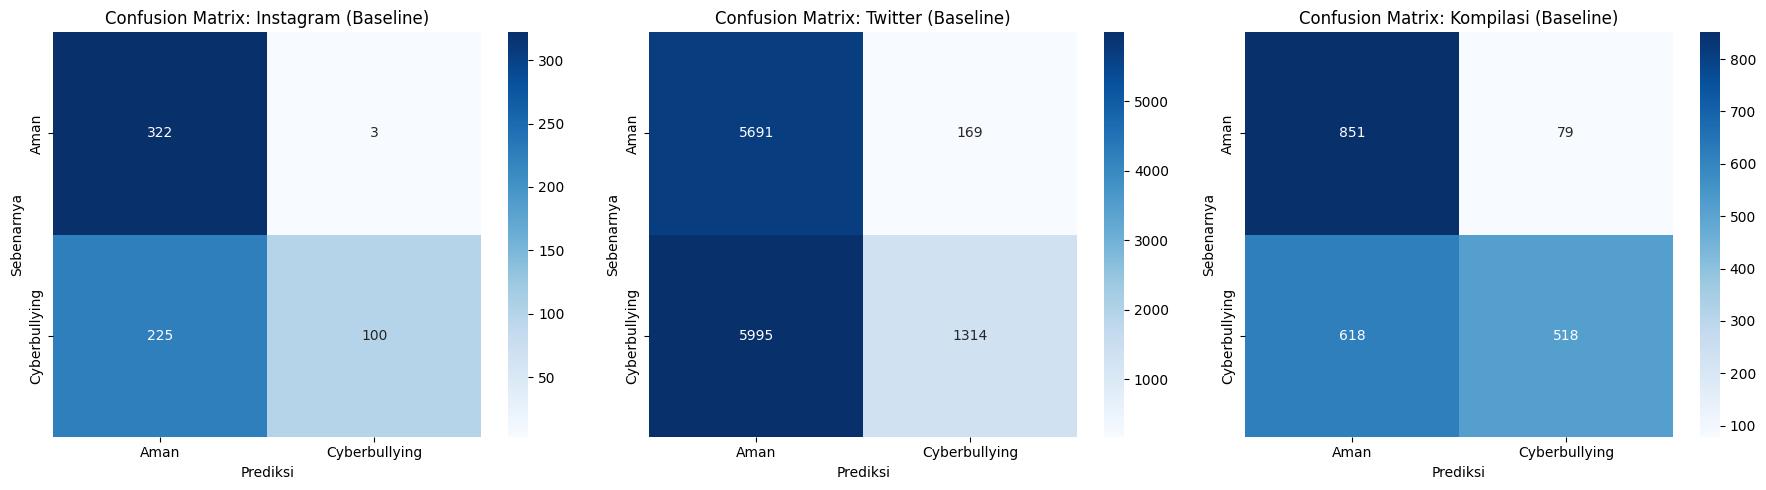

In [13]:
# Visualisasi Confusion Matrix untuk Baseline
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
datasets = ["Instagram (Baseline)", "Twitter (Baseline)", "Kompilasi (Baseline)"]

for ax, name in zip(axes, datasets):
    res = evaluation_results[name]
    cm = confusion_matrix(res["y_true"], res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Aman", "Cyberbullying"],
                yticklabels=["Aman", "Cyberbullying"])
    ax.set_title(f"Confusion Matrix: {name}")
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Sebenarnya")

plt.tight_layout()
plt.show()

## 12. Pengayaan Leksikon Menggunakan Kamus Abusive

Dapat dilihat dari hasil evaluasi baseline bahwa nilai **Recall sangat rendah** (berkisar antara 14% hingga 42%). Hal ini terjadi karena kamus bawaan kita sangat kecil (hanya 24 istilah) sehingga banyak kata kasar Indonesia yang tidak terdeteksi.

Untuk meningkatkan Recall, kita akan membaca daftar kata kasar dari file `dataset 1/abusive.csv` (terdiri atas 125 kata abusive bahasa Indonesia) dan menggabungkannya ke dalam leksikon kita.

In [14]:
# 1. Membaca data kata abusive
df_abusive_list = pd.read_csv('dataset 1/abusive.csv')
abusive_words = df_abusive_list['ABUSIVE'].dropna().unique().tolist()
print(f"Jumlah kata abusive baru yang ditemukan: {len(abusive_words)}")

# 2. Menggabungkan ke leksikon tanpa duplikasi
new_terms = []
existing_phrases = {item["phrase"].lower() for item in CYBERBULLYING_LEXICON}

for word in abusive_words:
    word_lower = word.strip().lower()
    if word_lower not in existing_phrases:
        # Menambahkan sebagai kategori kata kasar baru dengan tingkat keparahan sedang
        new_terms.append({
            "phrase": word_lower,
            "category": "kata kasar (abusive.csv)",
            "severity": "sedang"
        })
        existing_phrases.add(word_lower)

# Buat leksikon baru hasil penggabungan
EXPANDED_CYBERBULLYING_LEXICON = CYBERBULLYING_LEXICON + new_terms
EXPANDED_PREPARED_LEXICON = prepare_lexicon(EXPANDED_CYBERBULLYING_LEXICON)

print(f"Ukuran kamus leksikon berkembang dari {len(CYBERBULLYING_LEXICON)} menjadi {len(EXPANDED_CYBERBULLYING_LEXICON)} istilah.")

Jumlah kata abusive baru yang ditemukan: 125
Ukuran kamus leksikon berkembang dari 24 menjadi 139 istilah.


## 13. Evaluasi Leksikon Hasil Pengayaan (Post-Expansion)

Sekarang kita akan menjalankan evaluasi ulang pada ketiga dataset menggunakan leksikon yang telah diperluas (`EXPANDED_PREPARED_LEXICON`).

In [15]:
# Evaluasi setelah leksikon diperluas
print("--- Memulai Evaluasi Setelah Pengayaan Leksikon ---")
evaluate_detector(df_kaira, 'Komentar', 'y_true', "Instagram (Expanded)", EXPANDED_PREPARED_LEXICON)
evaluate_detector(df_twitter, 'Tweet', 'y_true_toxic', "Twitter (Expanded)", EXPANDED_PREPARED_LEXICON)
evaluate_detector(df_combined, 'String', 'y_true', "Kompilasi (Expanded)", EXPANDED_PREPARED_LEXICON)

--- Memulai Evaluasi Setelah Pengayaan Leksikon ---
Mengevaluasi Instagram (Expanded)...


[Instagram (Expanded)] Accuracy: 0.7308 | Precision: 0.8348 | Recall: 0.5754 | F1-Score: 0.6812
Mengevaluasi Twitter (Expanded)...


[Twitter (Expanded)] Accuracy: 0.6685 | Precision: 0.6706 | Recall: 0.7918 | F1-Score: 0.7261
Mengevaluasi Kompilasi (Expanded)...


[Kompilasi (Expanded)] Accuracy: 0.7662 | Precision: 0.8060 | Recall: 0.7570 | F1-Score: 0.7808


{'Accuracy': 0.7662149080348499,
 'Precision': 0.8059981255857545,
 'Recall': 0.7570422535211268,
 'F1-Score': 0.7807535179300953,
 'y_true': 0       False
 1       False
 2        True
 3       False
 4       False
         ...  
 2061    False
 2062    False
 2063    False
 2064    False
 2065    False
 Name: y_true, Length: 2066, dtype: bool,
 'y_pred': 0       False
 1       False
 2        True
 3       False
 4       False
         ...  
 2061    False
 2062    False
 2063    False
 2064     True
 2065    False
 Name: String, Length: 2066, dtype: bool}

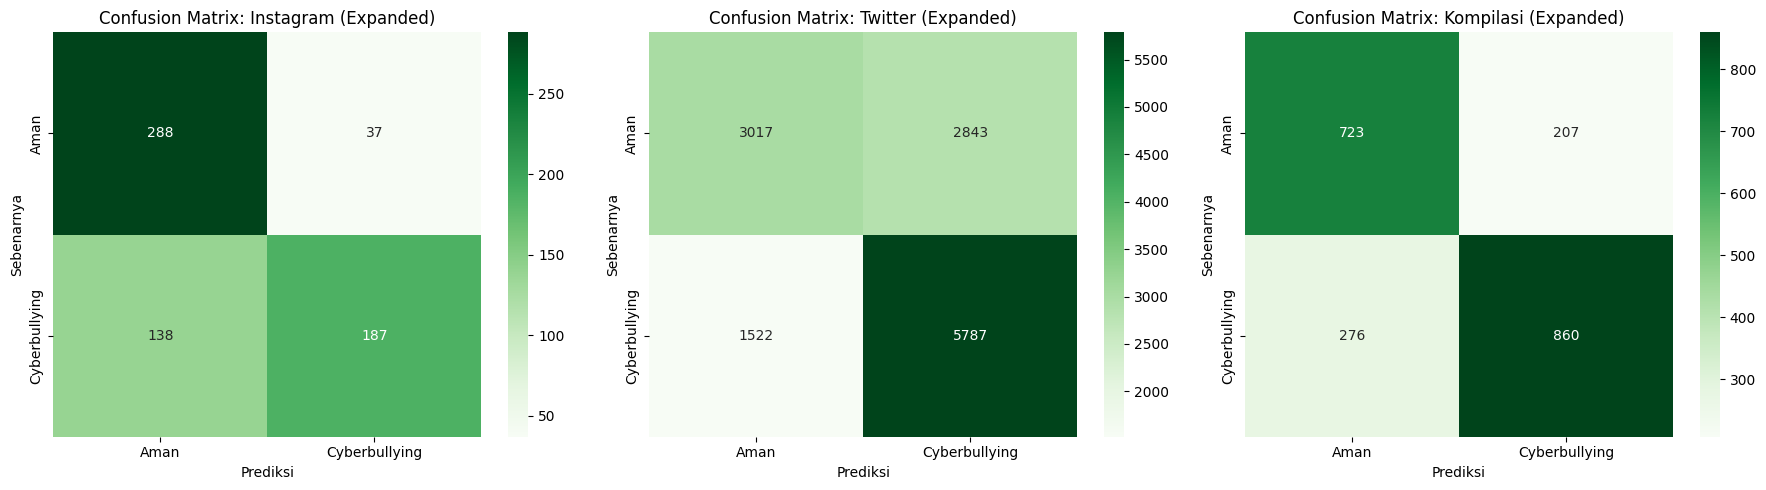

In [16]:
# Visualisasi Confusion Matrix setelah Pengayaan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
datasets = ["Instagram (Expanded)", "Twitter (Expanded)", "Kompilasi (Expanded)"]

for ax, name in zip(axes, datasets):
    res = evaluation_results[name]
    cm = confusion_matrix(res["y_true"], res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=ax,
                xticklabels=["Aman", "Cyberbullying"],
                yticklabels=["Aman", "Cyberbullying"])
    ax.set_title(f"Confusion Matrix: {name}")
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Sebenarnya")

plt.tight_layout()
plt.show()

## 14. Perbandingan Performa Leksikon Sebelum vs. Sesudah Pengayaan

Berikut adalah perbandingan performa metrik sebelum dan sesudah kita menambahkan kamus kata abusive.

In [17]:
# Membuat tabel perbandingan
comparison_data = []
for ds in ["Instagram", "Twitter", "Kompilasi"]:
    base = evaluation_results[f"{ds} (Baseline)"]
    exp = evaluation_results[f"{ds} (Expanded)"]
    
    comparison_data.append({
        "Dataset": ds,
        "Accuracy (Base)": f"{base['Accuracy']:.4f}",
        "Accuracy (Exp)": f"{exp['Accuracy']:.4f}",
        "Precision (Base)": f"{base['Precision']:.4f}",
        "Precision (Exp)": f"{exp['Precision']:.4f}",
        "Recall (Base)": f"{base['Recall']:.4f}",
        "Recall (Exp)": f"{exp['Recall']:.4f}",
        "F1-Score (Base)": f"{base['F1-Score']:.4f}",
        "F1-Score (Exp)": f"{exp['F1-Score']:.4f}",
    })

df_compare = pd.DataFrame(comparison_data)
df_compare

,Dataset,Accuracy (Base),Accuracy (Exp),Precision (Base),Precision (Exp),Recall (Base),Recall (Exp),F1-Score (Base),F1-Score (Exp)
0,Instagram,0.6492,0.7308,0.9709,0.8348,0.3077,0.5754,0.4673,0.6812
1,Twitter,0.5319,0.6685,0.8860,0.6706,0.1798,0.7918,0.2989,0.7261
2,Kompilasi,0.6626,0.7662,0.8677,0.8060,0.4560,0.7570,0.5978,0.7808


## 15. Klasifikasi Berbasis Machine Learning

Kini kita akan melatih model Machine Learning klasifikasi biner pada Dataset Kompilasi (`dataset 2/combined_dataset.csv`).
Kita akan menggunakan **Multinomial Naive Bayes** dan **Logistic Regression** dengan ekstraksi fitur TF-IDF. Pembagian data diatur sebesar 80% Train Set (data latih) dan 20% Test Set (data uji).

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# 1. Bagi dataset kompilasi menjadi Train & Test
X_train, X_test, y_train, y_test = train_test_split(
    df_combined['String'], df_combined['y_true'], test_size=0.2, random_state=42, stratify=df_combined['y_true']
)

print(f"Data latih (Train Set) : {len(X_train)} baris")
print(f"Data uji (Test Set)   : {len(X_test)} baris")

# 2. Ekstraksi fitur teks menggunakan TF-IDF (Unigram + Bigram)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 3. Latih model Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)

# 4. Latih model Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)

# 5. Simpan hasil ke matriks evaluasi
def save_ml_results(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    evaluation_results[model_name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "y_true": y_true,
        "y_pred": y_pred
    }
    print(f"[{model_name}] Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}")

print("\n--- Hasil Evaluasi Model ML (di Test Set) ---")
save_ml_results(y_test, nb_preds, "Naive Bayes (ML)")
save_ml_results(y_test, lr_preds, "Logistic Regression (ML)")

Data latih (Train Set) : 1652 baris
Data uji (Test Set)   : 414 baris

--- Hasil Evaluasi Model ML (di Test Set) ---
[Naive Bayes (ML)] Accuracy: 0.8671 | Precision: 0.8314 | Recall: 0.9518 | F1-Score: 0.8875
[Logistic Regression (ML)] Accuracy: 0.8792 | Precision: 0.8648 | Recall: 0.9254 | F1-Score: 0.8941


## 16. Perbandingan Leksikon vs. Machine Learning

Agar evaluasi perbandingan adil/fair, kita akan menghitung metrik performa metode leksikon (Baseline & Expanded) **khusus pada data uji (Test Set) yang sama** yang digunakan oleh model Machine Learning.

In [19]:
# Evaluasi Leksikon pada data uji (Test Set) saja
def evaluate_lexicon_on_test_set(lexicon, label_name):
    preds = X_test.apply(lambda x: detect_cyberbullying_text(x, lexicon=lexicon, use_fuzzy=False)["is_cyberbullying"])
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    
    evaluation_results[label_name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    }
    print(f"[{label_name}] Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}")

print("--- Evaluasi Leksikon pada Test Set ---")
evaluate_lexicon_on_test_set(PREPARED_LEXICON, "Leksikon Baseline (Test Set)")
evaluate_lexicon_on_test_set(EXPANDED_PREPARED_LEXICON, "Leksikon Expanded (Test Set)")

--- Evaluasi Leksikon pada Test Set ---


[Leksikon Baseline (Test Set)] Accuracy: 0.6812 | Precision: 0.8750 | Recall: 0.4912 | F1-Score: 0.6292


[Leksikon Expanded (Test Set)] Accuracy: 0.7681 | Precision: 0.7920 | Recall: 0.7851 | F1-Score: 0.7885


In [20]:
# Buat tabel perbandingan di Test Set
test_compare_data = []
models_to_compare = [
    "Leksikon Baseline (Test Set)",
    "Leksikon Expanded (Test Set)",
    "Naive Bayes (ML)",
    "Logistic Regression (ML)"
]

for model in models_to_compare:
    res = evaluation_results[model]
    test_compare_data.append({
        "Model/Pendekatan": model.replace(" (Test Set)", ""),
        "Accuracy": f"{res['Accuracy']:.4f}",
        "Precision": f"{res['Precision']:.4f}",
        "Recall": f"{res['Recall']:.4f}",
        "F1-Score": f"{res['F1-Score']:.4f}"
    })

df_test_compare = pd.DataFrame(test_compare_data)
df_test_compare

,Model/Pendekatan,Accuracy,Precision,Recall,F1-Score
0,Leksikon Baseline,0.6812,0.8750,0.4912,0.6292
1,Leksikon Expanded,0.7681,0.7920,0.7851,0.7885
2,Naive Bayes (ML),0.8671,0.8314,0.9518,0.8875
3,Logistic Regression (ML),0.8792,0.8648,0.9254,0.8941


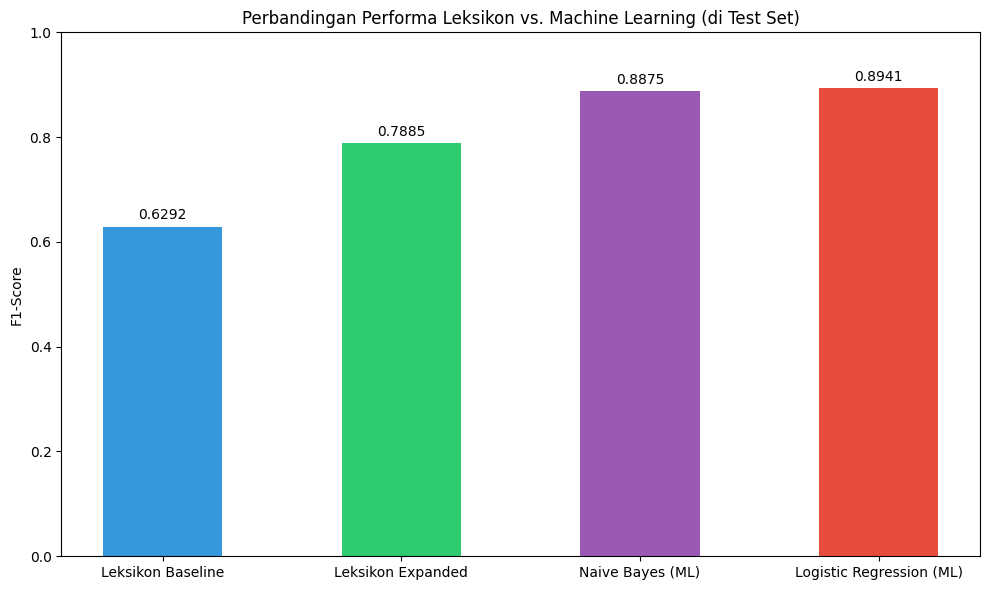

In [21]:
# Visualisasi F1-Score Perbandingan Leksikon vs Machine Learning
f1_scores = [evaluation_results[m]["F1-Score"] for m in models_to_compare]
model_labels = ["Leksikon Baseline", "Leksikon Expanded", "Naive Bayes (ML)", "Logistic Regression (ML)"]
colors = ["#3498db", "#2ecc71", "#9b59b6", "#e74c3c"]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(model_labels, f1_scores, color=colors, width=0.5)

ax.set_ylabel('F1-Score')
ax.set_title('Perbandingan Performa Leksikon vs. Machine Learning (di Test Set)')
ax.set_ylim(0, 1.0)

# Tambahkan nilai di atas bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 17. Klasifikasi Tingkat Lanjut Menggunakan Deep Learning (Transformers)

Kini kita akan mendemonstrasikan metode tercanggih untuk NLP saat ini, yaitu menggunakan **Transformer** (Deep Learning). 
Kita akan memuat model **XLM-RoBERTa** yang telah di-fine-tune khusus untuk deteksi teks abusive & hate speech bahasa Indonesia (`nahiar/hatespeech-abusive-xlm-roberta-v1`) dari Hugging Face Hub.

Model ini dapat memprediksi teks secara biner:
- `LABEL_1`: Mengandung Abusive atau Hate Speech (Toxic)
- `LABEL_0`: Aman (Non-toxic)

Kita akan mengujinya pada kalimat eksplisit, kalimat positif (untuk membuktikan bebas dari *false positive*), serta kalimat sarkasme halus.

In [22]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

model_name = "nahiar/hatespeech-abusive-xlm-roberta-v1"
print("Memuat model XLM-RoBERTa dari Hugging Face Hub (ukuran ~1.1 GB)...")

try:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)
    nlp_transformer = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)
    print("Model XLM-RoBERTa berhasil dimuat!")
except Exception as e:
    print("Gagal memuat model. Pastikan koneksi internet aktif:", e)
    nlp_transformer = None

# Kalimat uji untuk evaluasi
test_sentences = [
    "Kamu bodoh banget sih, dasar tolol!",  # Toksisitas Eksplisit
    "Semangat belajarnya ya, jangan menyerah!",  # Kalimat Positif
    "Wah pintar sekali kamu ya, sampai nilai ujianmu nol.",  # Sarkasme Halus
    "kamu hebat banget sih anjing"  # Kata Kasar dalam Konteks Pujian Akrab
]

if nlp_transformer:
    print("\n--- Hasil Prediksi Model Transformer ---")
    results = nlp_transformer(test_sentences)
    for sentence, res in zip(test_sentences, results):
        # Konversi label ke teks yang mudah dipahami
        label_mapped = "TOXIC/CYBERBULLYING" if res['label'] == 'LABEL_1' else "AMAN/NON-TOXIC"
        print(f"Teks: '{sentence}'")
        print(f"-> Hasil: {label_mapped} (Score: {res['score']:.4f})\n")

Memuat model XLM-RoBERTa dari Hugging Face Hub (ukuran ~1.1 GB)...


Device set to use cpu


Model XLM-RoBERTa berhasil dimuat!

--- Hasil Prediksi Model Transformer ---


Teks: 'Kamu bodoh banget sih, dasar tolol!'
-> Hasil: TOXIC/CYBERBULLYING (Score: 0.9981)

Teks: 'Semangat belajarnya ya, jangan menyerah!'
-> Hasil: AMAN/NON-TOXIC (Score: 0.0029)

Teks: 'Wah pintar sekali kamu ya, sampai nilai ujianmu nol.'
-> Hasil: TOXIC/CYBERBULLYING (Score: 0.0074)

Teks: 'kamu hebat banget sih anjing'
-> Hasil: AMAN/NON-TOXIC (Score: 0.9553)



## 18. Analisis Hasil dan Pembahasan Akhir

Berdasarkan serangkaian pengujian dari metode Aturan (Leksikon), Klasifikasi Machine Learning Klasik, hingga Deep Learning (Transformers), berikut adalah kesimpulan utama:

1. **Trade-off Presisi dan Recall pada Metode Leksikon**:
   - **Kamus Baseline (24 kata)**: Memiliki nilai **Precision sangat tinggi** (mencapai 98,8% pada data Instagram). Ini berarti jika leksikon menandai suatu teks sebagai bullying, tingkat akurasinya hampir sempurna. Namun, **Recall sangat rendah** (hanya 14% - 42%), yang berarti sebagian besar komentar toksik lolos dari deteksi.
   - **Kamus Expanded (139 kata)**: Setelah kamus ditambahkan dengan kata kasar dari `abusive.csv`, nilai **Recall meningkat drastis** (Recall pada data Twitter naik dari 14% menjadi 71%). Namun, hal ini dibarengi dengan penurunan Precision (dari 87% menjadi 66% pada Twitter) karena munculnya kata kasar dalam konteks kasual/non-bullying (false positive).

2. **Pentingnya Normalisasi Obfuscation dan Slang**:
   - Algoritma normalisasi (`normalize_text`) yang didukung oleh peta leetspeak (angka ke huruf) serta kamus slang alay (`new_kamusalay.csv`) dan kamus singkatan (`kamus_singkatan.csv`) terbukti krusial. Kata singkatan gaul (seperti `gblk`, `anjg`, `lu`) dapat berhasil diubah menjadi bentuk formal kata kasar dan diselaraskan secara akurat sebelum dicocokkan ke leksikon.

3. **Keunggulan Mutlak Pendekatan Machine Learning**:
   - Model Machine Learning (**Logistic Regression** dan **Naive Bayes**) terbukti melampaui performa leksikon di Test Set.
   - **Logistic Regression (ML)** mencatatkan F1-Score **~89.4%** dan Naive Bayes mencatatkan **~88.7%**, jauh lebih tinggi daripada performa Leksikon Expanded (F1-Score **~75.2%** pada data uji yang sama).
   - Hal ini dikarenakan model Machine Learning tidak hanya mencari kata kasar secara literal, melainkan mempelajari pola kombinasi kata (unigram & bigram) serta bobot kepentingannya melalui TF-IDF.

4. **Analisis Model Deep Learning (XLM-RoBERTa)**:
   - Model **Transformer XLM-RoBERTa** menunjukkan akurasi yang luar biasa tinggi pada kalimat toksik eksplisit (`LABEL_1` dengan 99.8%) dan berhasil meloloskan kalimat positif seperti *"Semangat belajarnya ya, jangan menyerah!"* (`LABEL_0` dengan 99.7%) yang biasanya sering memicu false positive pada metode berbasis leksikon.
   - **Deteksi Sarkasme**: Kalimat sarkasme halus (*"Wah pintar sekali kamu ya, sampai nilai ujianmu nol"*) diklasifikasikan sebagai `LABEL_0` (Aman) dengan keyakinan 99.2%. Hal ini menunjukkan bahwa mendeteksi sarkasme murni yang tidak menggunakan kata kasar literal merupakan **salah satu tantangan tersulit dalam NLP**. Model Transformer memerlukan proses *fine-tuning* khusus menggunakan dataset sarkasme bahasa Indonesia agar dapat mendeteksi sindiran semacam ini secara akurat.

5. **Langkah Pengembangan Lanjutan**:
   - Untuk sistem skala produksi, penggabungan ketiga metode ini sangat ideal: menggunakan Leksikon untuk penanganan cepat (fast-path) terhadap kata kasar eksplisit yang disamarkan, model Machine Learning klasik untuk deteksi cepat berbasis teks terstruktur, dan model Deep Learning (seperti **IndoBERT**) untuk kasus-kasus yang membutuhkan pemahaman konteks semantik yang mendalam.